Dados IIoT
      ↓
Treinamento dos modelos
      ↓
(Logistic + DT + RF)
      ↓
evaluation.ipynb
      ↓
Accuracy
Precision
Recall
F1
Confusion Matrix
PCA
t-SNE
Feature Importance
      ↓
XAI
      ↓
SHAP
Erro (FP/FN)
Comparação entre modelos
Interpretação científica

# BIBLIOTECAS

In [116]:
# ============================================================
# OBJETIVO:
# Importar todas as bibliotecas necessárias.
#
# JUSTIFICATIVA ACADÊMICA:
#
# Trabalhos recentes em IDS/IIoT usando XAI
# normalmente utilizam:
#
# - Pandas → manipulação dos datasets
# - Numpy → operações matemáticas
# - Matplotlib/Seaborn → visualização
# - SHAP → interpretabilidade
#
# Exemplo:
#
# Hybrid Bagging and Boosting with SHAP (2024)
# XML Intrusion Detection (2024)
#
# SHAP tornou-se praticamente padrão
# para explicabilidade em IDS.
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

import gzip
import pickle

import copy

from pathlib import Path

from sklearn.metrics import confusion_matrix

# 2. CARREGAMENTO DOS DADOS

In [117]:
# ============================================================
# OBJETIVO:
# Recriar funções usadas durante
# o treinamento e salvas no pipeline
#
# JUSTIFICATIVA:
#
# Pickle salva referências para
# funções customizadas.
#
# Ao carregar em outro notebook,
# elas precisam existir novamente.
# ============================================================


def get_sampling_strategy(y):

    """
    Estratégia padrão para SMOTE
    usada durante o treinamento.
    """

    return "auto"

In [ ]:
# ============================================================
# OBJETIVO:
#
# Carregar:
#
# 1) Dataset de teste
# 2) Modelos treinados
# 3) Resultados do evaluations
#
# JUSTIFICATIVA:
#
# O dataset é usado para SHAP
#
# Os modelos são necessários
# para calcular explicabilidade
#
# O evaluations fornece:
#
# métricas
# confusion matrices
# PCA
# t-SNE
#
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "datasense" / "dataset"
RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
EVAL_DIR = PROJECT_ROOT / "experiments" / "evaluations"

# -----------------------------
# Dataset
# -----------------------------
X_test = pd.read_parquet(
    DATASET_DIR / "datasense_full_test_1sec.parquet"
)

y_test = X_test["label4"].copy()
X_test = X_test.drop(columns=["label1", "label2", "label4"], errors="ignore")

# -----------------------------
# Modelos
# -----------------------------
MODEL_PATHS = {
    "logistic_regression": RESULTS_DIR / "logistic_regression_full_all" / "pipe.pickle.gz",
    "decision_tree": RESULTS_DIR / "decision_tree_full_all" / "pipe.pickle.gz",
    "random_forest": RESULTS_DIR / "random_forest_full_all" / "pipe.pickle.gz"
}

MODELS = {}

for name, path in MODEL_PATHS.items():
    with gzip.open(path, "rb") as f:
        MODELS[name] = pickle.load(f)

# -----------------------------
# FIX: FEATURE ALIGNMENT GLOBAL
# -----------------------------

# usa um modelo como referência do treino
ref_model = MODELS["random_forest"]

if hasattr(ref_model, "named_steps"):
    try:
        expected_features = ref_model.named_steps["preprocessor"].get_feature_names_out()
    except:
        expected_features = X_test.columns
else:
    expected_features = X_test.columns

# garante alinhamento perfeito
X_test = X_test.reindex(columns=expected_features, fill_value=0)

print("Dataset final alinhado:", X_test.shape)

Dataset final alinhado: (56798, 108)


# 3. FEATURE IMPORTANCE + TOP FEATURES

In [120]:
feature_importance = pd.read_csv(
    EVAL_DIR / "feature_importances.csv"
)

feature_col = "feature"
importance_col = "binary_avg_importance"

TOP_N = 20

top_features = (
    feature_importance
    .sort_values(by=importance_col, ascending=False)
    .head(TOP_N)
)

selected_features = top_features[feature_col].tolist()

valid_features = [f for f in selected_features if f in X_test.columns]

X_xai = X_test[valid_features]

print("XAI dataset:", X_xai.shape)

XAI dataset: (56798, 20)


# 4. SHAP GLOBAL

In [121]:
def shap_global(values):
    values = np.array(values)

    if isinstance(values, list):
        values = values[1]

    return np.mean(np.abs(values), axis=0)


def get_shap(model, X_sample, name):

    # ---------------- TREE MODELS ----------------
    if "tree" in name or "forest" in name:

        if hasattr(model, "named_steps"):
            pre = model[:-1]
            final_model = model[-1]
            X_trans = pre.transform(X_sample)
        else:
            final_model = model
            X_trans = X_sample

        explainer = shap.TreeExplainer(final_model)
        values = explainer.shap_values(X_trans)

        return np.array(values), X_trans

    # ---------------- LINEAR MODEL ----------------
    elif "logistic" in name:

        if hasattr(model, "named_steps"):
            pre = model[:-1]
            final_model = model[-1]
            X_trans = pre.transform(X_sample)
        else:
            final_model = model
            X_trans = X_sample

        explainer = shap.LinearExplainer(final_model, X_trans)
        values = explainer.shap_values(X_trans)

        return values, X_trans

    else:
        raise ValueError("Modelo não suportado")

# 5. SHAP GLOBAL COMPARAÇÃO

In [125]:

# ============================================================
# SHAP GLOBAL SCORE (comparação entre modelos)
# ============================================================
def shap_score(values):
    values = np.array(values)

    if isinstance(values, list):
        values = values[1]

    return np.mean(np.abs(values))


# ============================================================
# SEPARAÇÃO PIPELINE (preprocessador + modelo)
# ============================================================
def split_pipeline(model):

    if hasattr(model, "named_steps"):
        return model[:-1], model[-1]

    return None, model


# ============================================================
# FUNÇÃO PRINCIPAL SHAP (ROBUSTA E PIPELINE-SAFE)
# ============================================================
def get_shap(model, X_sample, name):

    pre, final_model = split_pipeline(model)

    # ============================================================
    # TREE MODELS (Decision Tree / Random Forest)
    # ============================================================
    if "tree" in name or "forest" in name:

        if pre is not None:
            X_trans = pre.transform(X_sample)
        else:
            X_trans = X_sample

        explainer = shap.TreeExplainer(final_model)
        values = explainer.shap_values(X_trans)

        return values, X_trans

    # ============================================================
    # LINEAR MODELS (Logistic Regression)
    # ============================================================
    elif "logistic" in name:

        if pre is not None:
            X_trans = pre.transform(X_sample)
        else:
            X_trans = X_sample

        explainer = shap.LinearExplainer(final_model, X_trans)
        values = explainer.shap_values(X_trans)

        return values, X_trans

    # ============================================================
    # FALLBACK GENÉRICO (seguro)
    # ============================================================
    else:

        if pre is not None:
            X_trans = pre.transform(X_sample)
        else:
            X_trans = X_sample

        explainer = shap.Explainer(final_model, X_trans)
        shap_exp = explainer(X_trans)

        return shap_exp.values, X_trans


# ============================================================
# EXECUÇÃO
# ============================================================
sample = X_test.sample(300, random_state=42)

for name, model in MODELS.items():

    print("\nProcessing:", name)

    values, X_trans = get_shap(model, sample, name)

    print("SHAP OK:", name)
    print("Shape:", np.array(values).shape)


Processing: logistic_regression
SHAP OK: logistic_regression
Shape: (300, 49, 84)

Processing: decision_tree
SHAP OK: decision_tree
Shape: (300, 107, 84)

Processing: random_forest
SHAP OK: random_forest
Shape: (300, 107, 84)


# 6 FP / FN SHAP

In [128]:
def reduce_shap(values):

    values = np.array(values)

    if isinstance(values, list):
        values = values[1]

    if values.ndim == 3:
        values = np.mean(np.abs(values), axis=(0, 2))

    elif values.ndim == 2:
        values = np.mean(np.abs(values), axis=0)

    return values


for name, model in MODELS.items():

    print("\n")
    print("="*50)
    print("MODEL:", name)
    print("="*50)

    pred = model.predict(X_test)

    errors = pd.DataFrame({
        "real": y_test.values,
        "pred": pred
    })

    FP_idx = errors[(errors.real == "benign") & (errors.pred != "benign")].index
    FN_idx = errors[(errors.real != "benign") & (errors.pred == "benign")].index
    TP_idx = errors[(errors.real != "benign") & (errors.pred != "benign")].index

    # ============================================================
    # 🔥 PRINT FP / FN (ANTES DA ANÁLISE SHAP)
    # ============================================================
    print("\n==================================================")
    print(f"FP: {len(FP_idx)}  FN: {len(FN_idx)}")
    print("==================================================\n")

    # ============================================================
    # SAMPLES
    # ============================================================
    X_tp = X_test.loc[TP_idx].sample(min(500, len(TP_idx)))
    X_fp = X_test.loc[FP_idx].sample(min(500, len(FP_idx)))
    X_fn = X_test.loc[FN_idx].sample(min(500, len(FN_idx)))

    # ============================================================
    # SHAP
    # ============================================================
    tp_s, _ = get_shap(model, X_tp, name)
    fp_s, _ = get_shap(model, X_fp, name)
    fn_s, _ = get_shap(model, X_fn, name)

    tp = reduce_shap(tp_s)
    fp = reduce_shap(fp_s)
    fn = reduce_shap(fn_s)

    # ============================================================
    # FEATURES
    # ============================================================
    features = X_test.columns[:len(tp)]

    df = pd.DataFrame({
        "feature": features,
        "TP_SHAP": tp,
        "FP_SHAP": fp,
        "FN_SHAP": fn
    })

    df["FP_minus_TP"] = df["FP_SHAP"] - df["TP_SHAP"]
    df["FN_minus_TP"] = df["FN_SHAP"] - df["TP_SHAP"]

    display(df.sort_values("FP_minus_TP", ascending=False).head(15))



MODEL: logistic_regression

FP: 17888  FN: 2051



,feature,TP_SHAP,FP_SHAP,FN_SHAP,FP_minus_TP,FN_minus_TP
18,network_ips_dst_count,0.487939,0.881355,0.000000,0.393416,-0.487939
4,network_header-length_avg,1.501684,1.889636,0.000000,0.387952,-1.501684
7,network_header-length_std_deviation,0.149747,0.528271,0.144143,0.378524,-0.005603
23,network_mss_avg,0.682049,0.957167,0.022914,0.275118,-0.659135
16,network_ip-length_std_deviation,0.139701,0.333171,0.010549,0.193470,-0.129152
17,network_ips_all_count,1.241176,1.358503,0.041475,0.117327,-1.199700
15,network_ip-length_min,0.013765,0.045019,0.020935,0.031253,0.007170
2,network_fragmentation-score,0.729055,0.746942,0.097794,0.017887,-0.631261
1,label3,0.000000,0.001308,0.000000,0.001308,0.000000
20,network_macs_all_count,0.000000,0.000000,0.000000,0.000000,0.000000




MODEL: decision_tree

FP: 4305  FN: 2414



,feature,TP_SHAP,FP_SHAP,FN_SHAP,FP_minus_TP,FN_minus_TP
106,network_ports_dst_has_557,0.001236,0.003009,0.001343,0.001773,0.000107
26,network_mss_std_deviation,0.001350,0.002738,0.002853,0.001387,0.001503
104,network_ports_dst_has_23,0.004929,0.006067,0.005263,0.001138,0.000334
54,network_time-delta_avg,0.000401,0.001496,0.001115,0.001095,0.000714
51,network_tcp-flags_max,0.003392,0.004332,0.004921,0.000940,0.001529
52,network_tcp-flags_min,0.001686,0.002538,0.001540,0.000852,-0.000145
23,network_mss_avg,0.000368,0.001168,0.001459,0.000801,0.001091
53,network_tcp-flags_std_deviation,0.000957,0.001710,0.001279,0.000753,0.000322
12,network_ip-flags_std_deviation,0.000819,0.001295,0.000813,0.000476,-0.000006
16,network_ip-length_std_deviation,0.001936,0.002397,0.001340,0.000461,-0.000596




MODEL: random_forest

FP: 7183  FN: 2071



,feature,TP_SHAP,FP_SHAP,FN_SHAP,FP_minus_TP,FN_minus_TP
0,device_name,0.002031,0.003395,0.002630,0.001364,0.000599
2,network_fragmentation-score,0.001464,0.002325,0.001594,0.000860,0.000130
28,network_packet-size_max,0.001019,0.001870,0.001637,0.000852,0.000619
1,label3,0.000307,0.000939,0.000441,0.000632,0.000135
57,network_time-delta_std_deviation,0.000151,0.000653,0.000198,0.000503,0.000047
56,network_time-delta_min,0.000395,0.000852,0.000352,0.000457,-0.000043
29,network_packet-size_min,0.000490,0.000910,0.000823,0.000420,0.000333
59,network_ttl_max,0.000796,0.001060,0.000766,0.000264,-0.000030
30,network_packet-size_std_deviation,0.000150,0.000328,0.000322,0.000178,0.000172
54,network_time-delta_avg,0.000951,0.001106,0.001415,0.000155,0.000464


# 7. SHAP VISUAL GLOBAL



MODEL: logistic_regression
Raw SHAP shape: (1, 49, 84)


<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

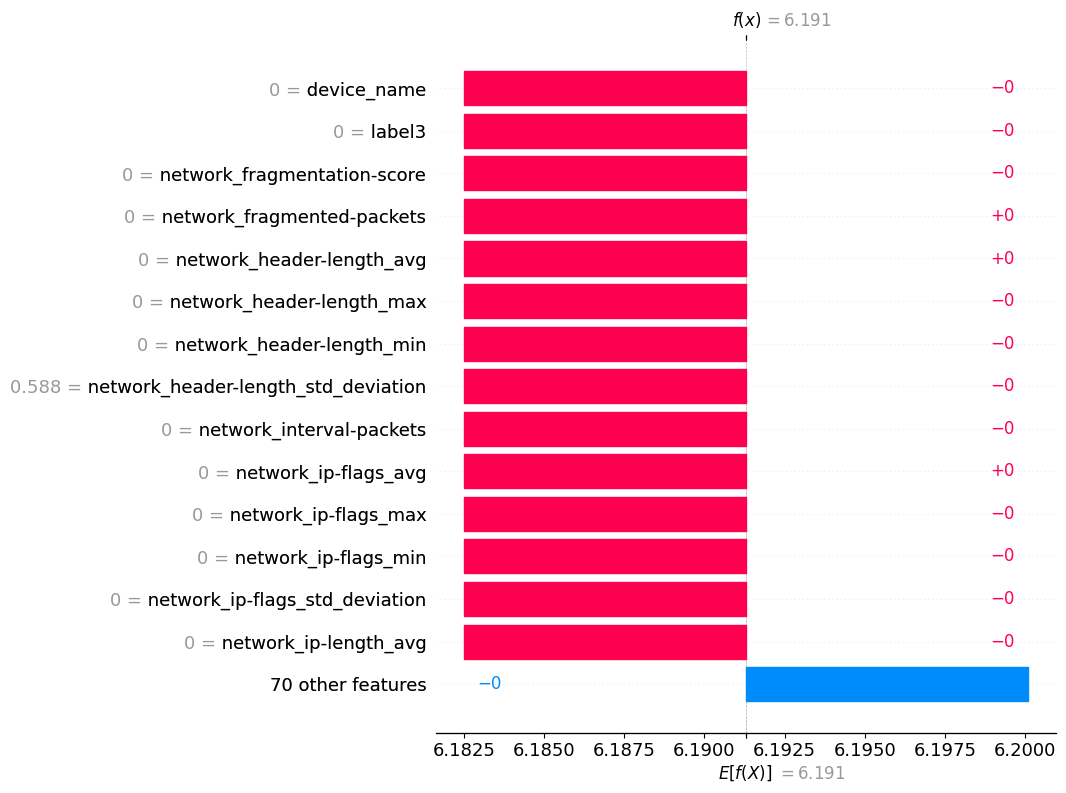



MODEL: decision_tree
Raw SHAP shape: (1, 107, 84)


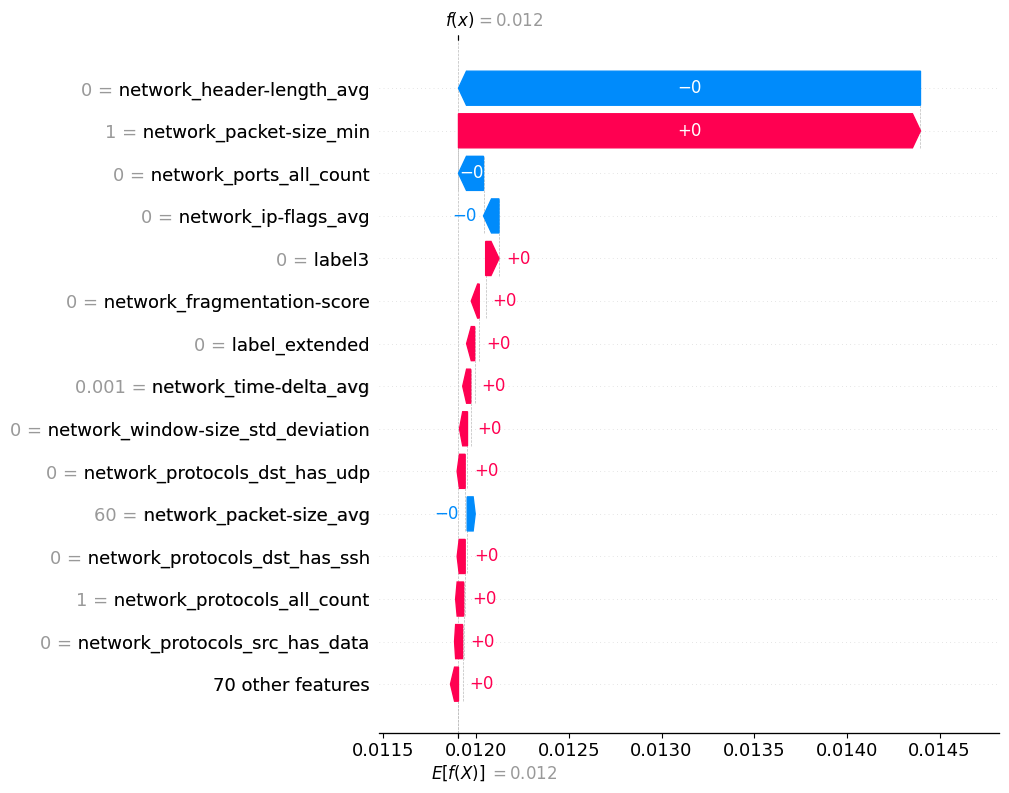



MODEL: random_forest
Raw SHAP shape: (1, 107, 84)


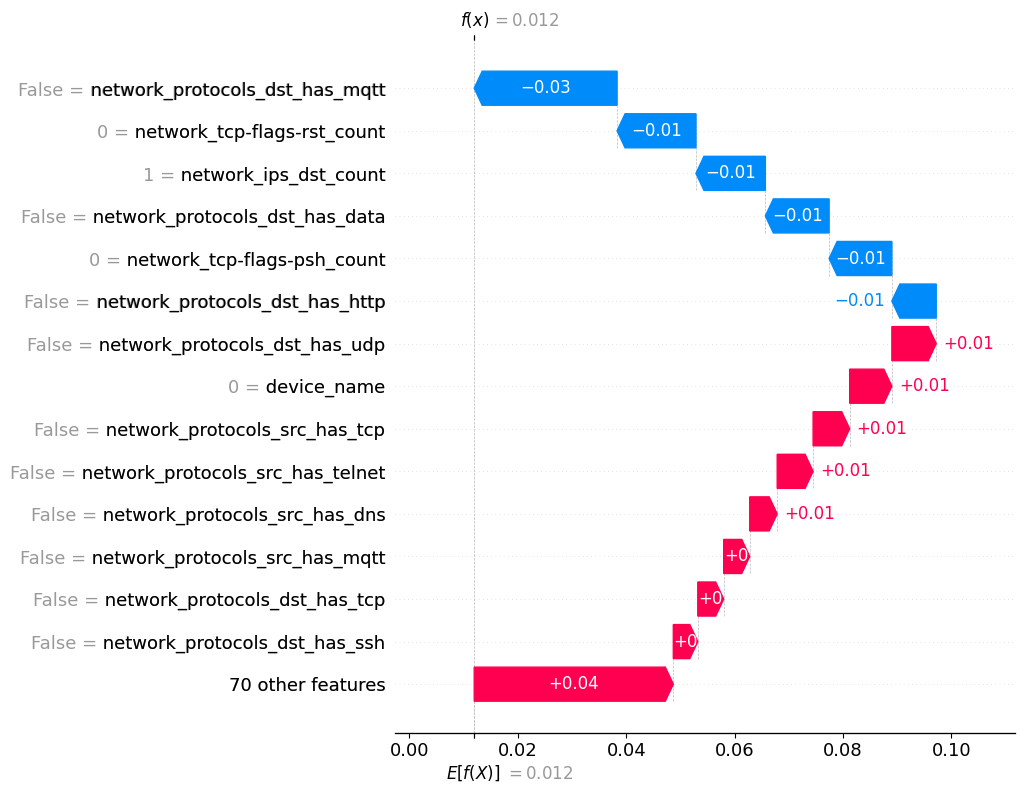

In [134]:
sample = X_test.sample(
    n=1,
    random_state=42
)

for name, model in MODELS.items():

    print("\n")
    print("="*60)
    print("MODEL:", name)
    print("="*60)

    pre, final_model = split_pipeline(model)

    # ============================================================
    # RESPEITA SCHEMA DO PIPELINE
    # ============================================================

    if pre is not None:

        cols = pre.feature_names_in_

        X_fixed = sample.reindex(
            columns=cols,
            fill_value=0
        )

        X_trans = pre.transform(
            X_fixed
        )

    else:

        X_trans = sample


    # ============================================================
    # CALCULA SHAP
    # ============================================================

    if "tree" in name or "forest" in name:

        explainer = shap.TreeExplainer(
            final_model
        )

        values = explainer.shap_values(
            X_trans
        )

        base = explainer.expected_value


    elif "logistic" in name:

        explainer = shap.LinearExplainer(
            final_model,
            X_trans
        )

        values = explainer.shap_values(
            X_trans
        )

        base = explainer.expected_value


    else:

        explainer = shap.Explainer(
            final_model,
            X_trans
        )

        exp = explainer(
            X_trans
        )

        values = exp.values
        base = exp.base_values


    # ============================================================
    # NORMALIZA DIMENSÕES
    # ============================================================

    values = np.array(values)

    print("Raw SHAP shape:", values.shape)

    # Caso: lista multiclass
    if isinstance(values, list):

        values = values[1]

    values = np.array(values)


    # (classes, amostras, features)
    if values.ndim == 3:

        values = values[0,0,:]

        if isinstance(base, (list,np.ndarray)):
            base = base[0]

    # (amostras,features)
    elif values.ndim == 2:

        values = values[0]

        if isinstance(base,(list,np.ndarray)):
            base = base[0]


    explanation = shap.Explanation(
        values=values,
        base_values=base,
        data=X_trans[0],
        feature_names=sample.columns
    )


    # ============================================================
    # WATERFALL
    # ============================================================

    plt.figure(figsize=(12,7))

    shap.plots.waterfall(
        explanation,
        max_display=15,
        show=False
    )

    plt.show()

# 8. ANÁLISE CIENTÍFICA AUTOMÁTICA FP vs FN

In [131]:
# ============================================================
# Objetivo:
# Interpretar automaticamente as causas dos erros
# usando SHAP
#
# Gera:
# - Top drivers de FP
# - Top drivers de FN
# - Diagnóstico automático
# ============================================================

TOP_K = 5

for name, model in MODELS.items():

    print("\n")
    print("="*70)
    print("MODELO:", name.upper())
    print("="*70)

    pred = model.predict(X_test)

    errors = pd.DataFrame({
        "real": y_test.values,
        "pred": pred
    })

    FP_idx = errors[
        (errors.real=="benign") &
        (errors.pred!="benign")
    ].index

    FN_idx = errors[
        (errors.real!="benign") &
        (errors.pred=="benign")
    ].index

    TP_idx = errors[
        (errors.real!="benign") &
        (errors.pred!="benign")
    ].index

    print(f"\nFP: {len(FP_idx)}")
    print(f"FN: {len(FN_idx)}")
    print(f"TP: {len(TP_idx)}")


    # ============================================================
    # amostragem
    # ============================================================

    X_tp = X_test.loc[TP_idx].sample(
        min(500,len(TP_idx)),
        random_state=42
    )

    X_fp = X_test.loc[FP_idx].sample(
        min(500,len(FP_idx)),
        random_state=42
    )

    X_fn = X_test.loc[FN_idx].sample(
        min(500,len(FN_idx)),
        random_state=42
    )


    # ============================================================
    # SHAP
    # ============================================================

    tp_s,_ = get_shap(
        model,
        X_tp,
        name
    )

    fp_s,_ = get_shap(
        model,
        X_fp,
        name
    )

    fn_s,_ = get_shap(
        model,
        X_fn,
        name
    )


    tp = reduce_shap(tp_s)
    fp = reduce_shap(fp_s)
    fn = reduce_shap(fn_s)


    features = X_test.columns[:len(tp)]

    df = pd.DataFrame({

        "feature":features,
        "TP":tp,
        "FP":fp,
        "FN":fn

    })


    df["FP_minus_TP"] = (
        df["FP"] - df["TP"]
    )

    df["FN_minus_TP"] = (
        df["FN"] - df["TP"]
    )


    top_fp = (
        df
        .sort_values(
            "FP_minus_TP",
            ascending=False
        )
        .head(TOP_K)
    )


    top_fn = (
        df
        .sort_values(
            "FN_minus_TP",
            ascending=False
        )
        .head(TOP_K)
    )


    print("\n")
    print("-"*50)
    print("TOP FEATURES ASSOCIADAS A FP")
    print("-"*50)

    display(
        top_fp[
            ["feature","FP_minus_TP"]
        ]
    )


    print("\n")
    print("-"*50)
    print("TOP FEATURES ASSOCIADAS A FN")
    print("-"*50)

    display(
        top_fn[
            ["feature","FN_minus_TP"]
        ]
    )


    # ============================================================
    # INSIGHTS AUTOMÁTICOS
    # ============================================================

    fp_features = top_fp.feature.tolist()
    fn_features = top_fn.feature.tolist()

    print("\n")
    print("INSIGHT CIENTÍFICO:")
    print("-"*50)

    print(
        f"O modelo {name} apresentou "
        f"maior sensibilidade a "
        f"{', '.join(fp_features[:3])}, "
        f"o que parece contribuir "
        f"para falsos positivos."
    )

    print()

    print(
        f"Os falsos negativos estão "
        f"mais associados a "
        f"{', '.join(fn_features[:3])}, "
        f"sugerindo possível perda "
        f"de padrões discriminativos."
    )

    print()

    if len(FP_idx) > len(FN_idx):

        print(
            "Diagnóstico: o modelo tende "
            "a superestimar ataques "
            "(maior taxa de falso positivo)."
        )

    else:

        print(
            "Diagnóstico: o modelo tende "
            "a subestimar ataques "
            "(maior taxa de falso negativo)."
        )



MODELO: LOGISTIC_REGRESSION

FP: 17888
FN: 2051
TP: 20547


--------------------------------------------------
TOP FEATURES ASSOCIADAS A FP
--------------------------------------------------


,feature,FP_minus_TP
4,network_header-length_avg,0.367879
23,network_mss_avg,0.358420
2,network_fragmentation-score,0.211154
7,network_header-length_std_deviation,0.208708
16,network_ip-length_std_deviation,0.193059




--------------------------------------------------
TOP FEATURES ASSOCIADAS A FN
--------------------------------------------------


,feature,FN_minus_TP
7,network_header-length_std_deviation,0.012071
15,network_ip-length_min,0.012036
1,label3,0.000000
21,network_macs_dst_count,0.000000
20,network_macs_all_count,0.000000




INSIGHT CIENTÍFICO:
--------------------------------------------------
O modelo logistic_regression apresentou maior sensibilidade a network_header-length_avg, network_mss_avg, network_fragmentation-score, o que parece contribuir para falsos positivos.

Os falsos negativos estão mais associados a network_header-length_std_deviation, network_ip-length_min, label3, sugerindo possível perda de padrões discriminativos.

Diagnóstico: o modelo tende a superestimar ataques (maior taxa de falso positivo).


MODELO: DECISION_TREE

FP: 4305
FN: 2414
TP: 20184


--------------------------------------------------
TOP FEATURES ASSOCIADAS A FP
--------------------------------------------------


...



INSIGHT CIENTÍFICO:
--------------------------------------------------
O modelo decision_tree apresentou maior sensibilidade a network_ports_dst_has_557, network_mss_std_deviation, network_time-delta_avg, o que parece contribuir para falsos positivos.

Os falsos negativos estão mais associados a network_tcp-flags_max, network_mss_std_deviation, network_mss_avg, sugerindo possível perda de padrões discriminativos.

Diagnóstico: o modelo tende a superestimar ataques (maior taxa de falso positivo).


MODELO: RANDOM_FOREST

FP: 7183
FN: 2071
TP: 20527


--------------------------------------------------
TOP FEATURES ASSOCIADAS A FP
--------------------------------------------------


,feature,FP_minus_TP
0,device_name,0.001351
2,network_fragmentation-score,0.000838
28,network_packet-size_max,0.000830
1,label3,0.000641
57,network_time-delta_std_deviation,0.000493




--------------------------------------------------
TOP FEATURES ASSOCIADAS A FN
--------------------------------------------------


,feature,FN_minus_TP
28,network_packet-size_max,0.000571
0,device_name,0.000555
54,network_time-delta_avg,0.000433
29,network_packet-size_min,0.000293
26,network_mss_std_deviation,0.000265




INSIGHT CIENTÍFICO:
--------------------------------------------------
O modelo random_forest apresentou maior sensibilidade a device_name, network_fragmentation-score, network_packet-size_max, o que parece contribuir para falsos positivos.

Os falsos negativos estão mais associados a network_packet-size_max, device_name, network_time-delta_avg, sugerindo possível perda de padrões discriminativos.

Diagnóstico: o modelo tende a superestimar ataques (maior taxa de falso positivo).
